# 並列対戦 → self/相手モデル継続学習ループ（AdamW state継続 + MCTS温度版）

既存のstateful AdamW学習ループに、worker-batched MCTSの**最終行動選択温度**を追加した版です。

実際の `tools/batched_tournament.py` を確認したうえで、最終行動選択を行っている
`_finish_search(context)` の `max visit` 選択だけを温度付きvisit samplingへ変更します。

温度は

\[
\tau(e,t)
=
\tau_{\mathrm{final}}
+
(\tau_{\mathrm{initial}}-\tau_{\mathrm{final}})
\exp\left(
-\alpha\frac{e}{E}
-\beta\frac{t}{T}
\right)
\]

で計算します。

- `e`: その対戦バッチ開始時点ですでに学習済みの累計episode数
- `E`: 今回の学習終了時の累計episode数
- `t`: `current["turn"]`
- `T`: `MAX_TURNS`
- `tau_initial = 1.2`
- `tau_final = 0.15`
- `episode_decay = 1.0`
- `turn_decay = 2.0`

MCTS prior の既存 `exp(policy * 10)` は、この変更では触りません。


In [19]:
from __future__ import annotations

from datetime import datetime
from contextlib import contextmanager
import importlib
import math
import os
import re
import shutil
import textwrap
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import clear_output, display


def find_match_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'tools' / 'run_matches_round_robin.py').exists():
            return candidate
    raise FileNotFoundError('並列対戦リポジトリが見つかりません。')


MATCH_ROOT = find_match_root()
TRAIN_ROOT = MATCH_ROOT.parent / 'pokemon-tcg-agent-nomura'
RUNNER = MATCH_ROOT / 'tools' / 'run_matches_round_robin.py'
BATCHED_TOURNAMENT = MATCH_ROOT / 'tools' / 'batched_tournament.py'
PREPROCESSOR = TRAIN_ROOT / 'tools' / 'train' / 'preprocess_match_agents.py'
BASE_TRAIN_SCRIPT = TRAIN_ROOT / 'tools' / 'train' / 'train_imitation.py'
STATEFUL_TRAIN_SCRIPT = MATCH_ROOT / 'results' / '_generated' / 'train_imitation_stateful.py'
PARALLEL_TRAINER = MATCH_ROOT / 'tools' / 'benchmark_parallel_training.py'
venv_python = MATCH_ROOT / '.venv' / ('Scripts/python.exe' if os.name == 'nt' else 'bin/python')
PYTHON = venv_python if venv_python.exists() else Path(sys.executable)
for required in (RUNNER, BATCHED_TOURNAMENT, PREPROCESSOR, BASE_TRAIN_SCRIPT, PARALLEL_TRAINER):
    if not required.exists():
        raise FileNotFoundError(f'並列学習に必要なスクリプトがありません: {required}')
if str(MATCH_ROOT) not in sys.path:
    sys.path.insert(0, str(MATCH_ROOT))

import tools.parallel_selfplay_training as selfplay_training
importlib.reload(selfplay_training)
run_parallel_games = selfplay_training.run_parallel_games
train_models = selfplay_training.train_models
read_parallel_training_metrics = selfplay_training.read_parallel_training_metrics
MODEL_SOURCE_ROOT = MATCH_ROOT / 'agents' / 'rl_mcts' / 'src'
if str(MODEL_SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODEL_SOURCE_ROOT))
model_file = MODEL_SOURCE_ROOT / 'rl_mcts' / 'model.py'
if not model_file.exists():
    model_file = MODEL_SOURCE_ROOT / 'model.py'
if not model_file.exists():
    raise FileNotFoundError(f'rl_mcts.model source not found under {MODEL_SOURCE_ROOT}')
spec = importlib.util.spec_from_file_location('rl_mcts.model', model_file)
module = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = module
spec.loader.exec_module(module)
create_model = module.create_model

print(f'MATCH_ROOT={MATCH_ROOT}')
print(f'TRAIN_ROOT={TRAIN_ROOT}')
print(f'PYTHON={PYTHON}')

MATCH_ROOT=/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent
TRAIN_ROOT=/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent-nomura
PYTHON=/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent/.venv/bin/python


## worker-batched MCTSの温度付き行動選択

`tools/batched_tournament.py` の実装では、`_finish_search()` が `child.node.visit` 最大の子を最終手として返しています。このセルはその関数だけを厳密に置換します。期待した元コードが見つからない場合はエラーで停止し、推測で別箇所を変更しません。


In [20]:
TEMPERATURE_PATCH_MARKER = "SELFPLAY_ACTION_TEMPERATURE_PATCH_V1"
BATCHED_TOURNAMENT_BACKUP = (
    MATCH_ROOT / "results" / "_generated" / "batched_tournament_before_temperature.py"
)

ORIGINAL_FINISH_SEARCH = r'''def _finish_search(context: _SearchContext) -> list[int]:
    root = context.root
    if root is None or not root.children:
        observation = context.session.observation
        select = observation.get("select") or {}
        option_count = len(select.get("option", []))
        select_count = int(select.get("maxCount", 0))
        return random.sample(range(option_count), select_count)

    max_child: _Child | None = None
    max_visit = -1
    min_value = 10.0
    for child in root.children:
        if child.node is None:
            continue
        if child.node.visit > max_visit:
            max_child = child
            max_visit = child.node.visit
        min_value = min(
            min_value,
            child.node.total / max(child.node.visit, 1),
        )
    if max_child is None:
        max_child = max(root.children, key=lambda child: child.probability)

    sample = context.root_sample
    if sample is not None:
        sample.value = root.total / max(root.visit, 1)
        if min_value == 10.0:
            min_value = sample.value
        for index, child in enumerate(root.children):
            value = sample.value
            if child.node is None:
                value = min_value - value - 0.03
            else:
                value = child.node.total / max(child.node.visit, 1) - value
            sample.policy[index] = max(-1.0, min(1.0, value))
    return max_child.select'''

PATCHED_FINISH_SEARCH = r'''# SELFPLAY_ACTION_TEMPERATURE_PATCH_V1
def _selfplay_action_temperature(context: _SearchContext) -> float | None:
    """自己対戦学習時だけ、累計学習episode数とturn数から行動選択温度を返す。"""
    if os.environ.get("SELFPLAY_ACTION_TEMPERATURE_ENABLED") != "1":
        return None

    tau_initial = float(os.environ["SELFPLAY_TEMPERATURE_INITIAL"])
    tau_final = float(os.environ["SELFPLAY_TEMPERATURE_FINAL"])
    episode_decay = float(os.environ["SELFPLAY_TEMPERATURE_EPISODE_DECAY"])
    turn_decay = float(os.environ["SELFPLAY_TEMPERATURE_TURN_DECAY"])
    trained_episodes = max(
        int(os.environ["SELFPLAY_TEMPERATURE_TRAINED_EPISODES"]),
        0,
    )
    total_episodes = max(
        int(os.environ["SELFPLAY_TEMPERATURE_TOTAL_EPISODES"]),
        1,
    )
    max_turns = max(
        int(os.environ["SELFPLAY_TEMPERATURE_MAX_TURNS"]),
        1,
    )

    episode_progress = min(
        max(trained_episodes / total_episodes, 0.0),
        1.0,
    )
    turn_progress = min(
        max(_raw_turn(context.session) / max_turns, 0.0),
        1.0,
    )
    return tau_final + (tau_initial - tau_final) * math.exp(
        -episode_decay * episode_progress
        -turn_decay * turn_progress
    )


def _sample_child_by_visit_temperature(
    children: list[_Child],
    temperature: float,
) -> _Child | None:
    """visit countを N^(1/tau) に変換して子ノードをサンプリングする。"""
    visited_children = [
        child
        for child in children
        if child.node is not None
    ]
    if not visited_children:
        return None

    if temperature <= 1e-8:
        return max(
            visited_children,
            key=lambda child: child.node.visit,
        )

    visits = [
        max(int(child.node.visit), 0)
        for child in visited_children
    ]
    if max(visits, default=0) <= 0:
        return None

    inverse_temperature = 1.0 / temperature
    log_weights = [
        (
            -math.inf
            if visit <= 0
            else inverse_temperature * math.log(visit)
        )
        for visit in visits
    ]
    max_log_weight = max(log_weights)
    weights = [
        (
            0.0
            if log_weight == -math.inf
            else math.exp(log_weight - max_log_weight)
        )
        for log_weight in log_weights
    ]
    return random.choices(
        visited_children,
        weights=weights,
        k=1,
    )[0]


def _finish_search(context: _SearchContext) -> list[int]:
    root = context.root
    if root is None or not root.children:
        observation = context.session.observation
        select = observation.get("select") or {}
        option_count = len(select.get("option", []))
        select_count = int(select.get("maxCount", 0))
        return random.sample(range(option_count), select_count)

    max_child: _Child | None = None
    max_visit = -1
    min_value = 10.0
    for child in root.children:
        if child.node is None:
            continue
        if child.node.visit > max_visit:
            max_child = child
            max_visit = child.node.visit
        min_value = min(
            min_value,
            child.node.total / max(child.node.visit, 1),
        )
    if max_child is None:
        max_child = max(root.children, key=lambda child: child.probability)

    temperature = _selfplay_action_temperature(context)
    if temperature is not None:
        sampled_child = _sample_child_by_visit_temperature(
            root.children,
            temperature,
        )
        if sampled_child is not None:
            max_child = sampled_child

    sample = context.root_sample
    if sample is not None:
        sample.value = root.total / max(root.visit, 1)
        if min_value == 10.0:
            min_value = sample.value
        for index, child in enumerate(root.children):
            value = sample.value
            if child.node is None:
                value = min_value - value - 0.03
            else:
                value = child.node.total / max(child.node.visit, 1) - value
            sample.policy[index] = max(-1.0, min(1.0, value))
    return max_child.select'''


def ensure_temperature_patch() -> None:
    source = BATCHED_TOURNAMENT.read_text(encoding="utf-8")

    if TEMPERATURE_PATCH_MARKER in source:
        print(f"temperature patch already present: {BATCHED_TOURNAMENT}")
        return

    occurrences = source.count(ORIGINAL_FINISH_SEARCH)
    if occurrences != 1:
        raise RuntimeError(
            "_finish_search() の期待した元実装を一意に確認できません。"
            f" occurrences={occurrences}. 推測で変更せず停止します。"
        )

    BATCHED_TOURNAMENT_BACKUP.parent.mkdir(parents=True, exist_ok=True)
    if not BATCHED_TOURNAMENT_BACKUP.exists():
        shutil.copy2(BATCHED_TOURNAMENT, BATCHED_TOURNAMENT_BACKUP)

    patched = source.replace(
        ORIGINAL_FINISH_SEARCH,
        PATCHED_FINISH_SEARCH,
        1,
    )

    # 書き込む前にPython構文として検証する。
    compile(
        patched,
        str(BATCHED_TOURNAMENT),
        "exec",
    )

    temporary = BATCHED_TOURNAMENT.with_name(
        f".{BATCHED_TOURNAMENT.name}.{os.getpid()}.tmp"
    )
    try:
        temporary.write_text(patched, encoding="utf-8")
        os.replace(temporary, BATCHED_TOURNAMENT)
    finally:
        temporary.unlink(missing_ok=True)

    print(f"temperature patch applied: {BATCHED_TOURNAMENT}")
    print(f"backup: {BATCHED_TOURNAMENT_BACKUP}")


ensure_temperature_patch()


temperature patch already present: /Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent/tools/batched_tournament.py


## 継続AdamW / 学習率scheduler

このセルは元の `train_imitation.py` を変更せず、互換のstateful版を `results/_generated/` に生成します。通常の `model.pth` は従来どおり純粋なmodel state_dictのままなので、対戦コードとの互換性を壊しません。AdamWとschedulerの状態は別ファイルとして管理します。


In [21]:
STATEFUL_TRAIN_SCRIPT.parent.mkdir(parents=True, exist_ok=True)
stateful_source = r'''"""train_imitation.py compatible wrapper with persistent AdamW/scheduler state.

The ordinary model.pth remains a pure model.state_dict() for compatibility.
Optimizer/scheduler/global-step are stored separately under SELFPLAY_TRAINING_STATE_ROOT.
"""
from __future__ import annotations

import argparse
import csv
import json
import os
import pickle
import random
import re
import sys
import time
from pathlib import Path
from typing import Iterator

REPO_ROOT = Path(__file__).resolve().parents[2]
# This generated script lives under MATCH_ROOT/results/_generated, so use the training worktree
# specified by the notebook for imports when available.
TRAIN_ROOT = Path(os.environ.get("SELFPLAY_TRAIN_ROOT", REPO_ROOT))
AGENT_ROOT = TRAIN_ROOT / "agents" / "rl_mcts"
SRC_ROOT = AGENT_ROOT / "src"
sys.path.insert(0, str(SRC_ROOT))

import torch
import torch.nn.functional as F
from rl_mcts.mcts import MAX_ACTIONS, LearnInput
from rl_mcts.model import create_model


def load_shard(path: Path) -> list[tuple]:
    with open(path, "rb") as f:
        return pickle.load(f)


def build_batch_tensors(batch: list[tuple], device: torch.device):
    input_enc = LearnInput(); input_dec = LearnInput()
    mask=[]; label_value=[]; chosen_indices=[]
    for enc_index, enc_value, enc_offset, dec_index, dec_value, dec_offset, chosen_index, value in batch:
        enc_count=len(input_enc.index); input_enc.index.extend(enc_index); input_enc.value.extend(enc_value)
        input_enc.offset.extend(o + enc_count for o in enc_offset)
        dec_count=len(input_dec.index); input_dec.index.extend(dec_index); input_dec.value.extend(dec_value)
        input_dec.offset.extend(o + dec_count for o in dec_offset)
        label_value.append(value); chosen_indices.append(chosen_index)
        n_candidates=len(dec_offset); mask.extend([1.0]*n_candidates)
        for _ in range(MAX_ACTIONS-n_candidates):
            mask.append(0.0); input_dec.offset.append(len(input_dec.index))
    n=len(batch)
    return (
        (
            torch.tensor(input_enc.index,dtype=torch.int32,device=device),
            torch.tensor(input_enc.value,dtype=torch.float32,device=device),
            torch.tensor(input_enc.offset,dtype=torch.int32,device=device),
            torch.tensor(input_dec.index,dtype=torch.int32,device=device),
            torch.tensor(input_dec.value,dtype=torch.float32,device=device),
            torch.tensor(input_dec.offset,dtype=torch.int32,device=device),
        ),
        torch.tensor(mask,dtype=torch.float32,device=device).view(n,-1),
        torch.tensor(label_value,dtype=torch.float32,device=device).view(n,-1),
        torch.tensor(chosen_indices,dtype=torch.long,device=device),
    )


def iter_batches(shard_paths:list[Path], batch_size:int, shuffle:bool)->Iterator[list[tuple]]:
    paths=list(shard_paths)
    if shuffle: random.shuffle(paths)
    for path in paths:
        samples=load_shard(path)
        if shuffle: random.shuffle(samples)
        for start in range(0,len(samples)-batch_size+1,batch_size):
            yield samples[start:start+batch_size]


def parse_args():
    p=argparse.ArgumentParser()
    p.add_argument('--shards',type=Path,required=True)
    p.add_argument('--val-shards',type=int,default=1)
    p.add_argument('--epochs',type=int,default=5)
    p.add_argument('--batch-size',type=int,default=128)
    p.add_argument('--lr',type=float,default=3e-4)
    p.add_argument('--initial-model',type=Path,default=None)
    p.add_argument('--output-model',type=Path,required=True)
    p.add_argument('--metrics-file',type=Path,required=True)
    p.add_argument('--seed',type=int,default=None)
    p.add_argument('--device',default='auto')
    return p.parse_args()


def select_device(name:str)->torch.device:
    normalized=name.lower()
    if normalized=='auto':
        normalized='cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
    device=torch.device(normalized)
    if device.type=='cuda' and not torch.cuda.is_available(): raise SystemExit('CUDAを利用できません。')
    if device.type=='mps' and not torch.backends.mps.is_available(): raise SystemExit('MPSを利用できません。')
    return device


def model_identity(*paths: Path|None) -> tuple[str,str]:
    text=' '.join(str(p) for p in paths if p is not None)
    m=re.search(r'cluster_\d+', text)
    if not m:
        raise SystemExit(f'optimizer state用のcluster名をパスから判定できません: {text}')
    role='opponent' if 'opponent_model' in text or 'opponent' in Path(str(paths[0])).stem else 'self'
    return m.group(0), role


def atomic_torch_save(obj, path:Path):
    path.parent.mkdir(parents=True,exist_ok=True)
    tmp=path.with_name(f'.{path.name}.{os.getpid()}.tmp')
    try:
        torch.save(obj,tmp); os.replace(tmp,path)
    finally:
        tmp.unlink(missing_ok=True)


def main():
    args=parse_args()
    if args.seed is not None:
        random.seed(args.seed); torch.manual_seed(args.seed)
    device=select_device(args.device); print(f'device: {device}')
    shard_paths=sorted(args.shards.glob('shard_*.pkl'))
    if not shard_paths: raise SystemExit(f'シャードが見つかりません: {args.shards}')
    random.shuffle(shard_paths)
    val_count=min(max(args.val_shards,0),max(len(shard_paths)-1,0))
    val_shards=shard_paths[:val_count]; train_shards=shard_paths[val_count:]
    print(f'train shards={len(train_shards)} val shards={len(val_shards)}')

    model=create_model().to(device)
    if args.initial_model and args.initial_model.exists():
        model.load_state_dict(torch.load(args.initial_model,map_location=device)); print(f'loaded initial weights: {args.initial_model}')

    optimizer=torch.optim.AdamW(model.parameters(),lr=args.lr)
    gamma=float(os.environ.get('SELFPLAY_LR_GAMMA','0.99995'))
    min_lr=float(os.environ.get('SELFPLAY_MIN_LR','3e-5'))
    min_factor=min_lr/args.lr
    scheduler=torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: max(min_factor, gamma ** step),
    )

    state_root=Path(os.environ['SELFPLAY_TRAINING_STATE_ROOT'])
    cluster,role=model_identity(args.output_model,args.initial_model)
    state_path=state_root/cluster/role/'training_state.pth'
    global_step=0
    if state_path.exists():
        state=torch.load(state_path,map_location=device)
        optimizer.load_state_dict(state['optimizer'])
        scheduler.load_state_dict(state['scheduler'])
        global_step=int(state.get('global_step',0))
        print(f'loaded training state: {state_path} global_step={global_step} lr={optimizer.param_groups[0]["lr"]:.8g}')
    else:
        print(f'new training state: {state_path}')

    args.output_model.parent.mkdir(parents=True,exist_ok=True); args.metrics_file.parent.mkdir(parents=True,exist_ok=True)
    fields=['epoch','batches','loss','loss_value','loss_policy','train_accuracy','val_accuracy','learning_rate','global_step','elapsed_seconds']
    with open(args.metrics_file,'w',newline='',encoding='utf-8') as f: csv.DictWriter(f,fieldnames=fields).writeheader()
    loss_fn_value=torch.nn.HuberLoss(delta=0.2); t0=time.time()

    for epoch in range(args.epochs):
        model.train(); batch_count=0; total_loss=total_lv=total_lp=0.0; correct=seen=0
        for batch in iter_batches(train_shards,args.batch_size,shuffle=True):
            tensors,mask_tensor,label_value_tensor,chosen_index_tensor=build_batch_tensors(batch,device)
            optimizer.zero_grad(); out_enc,out_dec=model(*tensors)
            lv=loss_fn_value(out_enc,label_value_tensor)
            logits=out_dec.masked_fill(mask_tensor==0,float('-inf'))
            lp=F.cross_entropy(logits,chosen_index_tensor); loss=lv+lp
            loss.backward(); optimizer.step(); scheduler.step(); global_step += 1
            with torch.no_grad(): correct += int((logits.argmax(dim=1)==chosen_index_tensor).sum().item()); seen += len(batch)
            total_loss += float(loss.item()); total_lv += float(lv.item()); total_lp += float(lp.item()); batch_count += 1

        model.eval(); vcorrect=vtotal=0
        with torch.no_grad():
            for batch in iter_batches(val_shards,args.batch_size,shuffle=False):
                tensors,mask_tensor,_,chosen=build_batch_tensors(batch,device); _,out_dec=model(*tensors)
                logits=out_dec.masked_fill(mask_tensor==0,float('-inf')); vcorrect += int((logits.argmax(dim=1)==chosen).sum().item()); vtotal += len(batch)
        stats={
            'epoch':epoch,'batches':batch_count,
            'loss':total_loss/batch_count if batch_count else 0.0,
            'loss_value':total_lv/batch_count if batch_count else 0.0,
            'loss_policy':total_lp/batch_count if batch_count else 0.0,
            'train_accuracy':correct/seen if seen else 0.0,
            'val_accuracy':vcorrect/vtotal if vtotal else 0.0,
            'learning_rate':optimizer.param_groups[0]['lr'],
            'global_step':global_step,'elapsed_seconds':time.time()-t0,
        }
        print(f"epoch={epoch} loss={stats['loss']:.4f} loss_value={stats['loss_value']:.4f} loss_policy={stats['loss_policy']:.4f} train_acc={stats['train_accuracy']:.3f} val_acc={stats['val_accuracy']:.3f} lr={stats['learning_rate']:.8g} global_step={global_step} elapsed={stats['elapsed_seconds']:.1f}s")
        with open(args.metrics_file,'a',newline='',encoding='utf-8') as f: csv.DictWriter(f,fieldnames=fields).writerow(stats)
        torch.save(model.state_dict(),args.output_model)
        atomic_torch_save({'optimizer':optimizer.state_dict(),'scheduler':scheduler.state_dict(),'global_step':global_step,'base_lr':args.lr,'gamma':gamma,'min_lr':min_lr},state_path)
    print(f'saved model: {args.output_model}')
    print(f'saved training state: {state_path}')

if __name__=='__main__': main()
'''
STATEFUL_TRAIN_SCRIPT.write_text(stateful_source, encoding='utf-8')
TRAIN_SCRIPT = STATEFUL_TRAIN_SCRIPT
print(f'stateful train script: {TRAIN_SCRIPT}')


stateful train script: /Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent/results/_generated/train_imitation_stateful.py


## 設定

指定したパスをモデルの保存先兼読み込み元にします。各重みファイルがあればそのまま初期重みに使い、なければランダム初期重みを生成します。論理CPUを1つ中央処理用に残し、残りをゲームworkerと学習workerにします。1回のモデル更新までに回す試合数は `GAME_WORKERS × LANES_PER_WORKER`、学習内部のミニバッチサイズは `TRAIN_MINIBATCH_SIZE` です。学習中は全self/相手モデルの平均loss・value loss・policy loss・accuracyをリアルタイム更新します。CPU/GPU/RAM使用率などの計測処理はありません。

In [22]:
TRAINING_AGENTS_ROOT = (
    MATCH_ROOT / 'agents' / '16model_pretrained_temperature_turn'
)
AGENTS = {
    f'cluster_{index:02d}': (
        TRAINING_AGENTS_ROOT / f'cluster_{index:02d}' / 'src' / 'main.py'
    )
    for index in range(16)
}

SEED = 0


def ensure_model_file(model_path: Path, seed: int) -> str:
    if model_path.is_file():
        return 'existing'
    if model_path.exists():
        raise FileExistsError(f'モデル保存先がファイルではありません: {model_path}')
    torch.manual_seed(seed)
    temporary = model_path.with_name(
        f'.{model_path.name}.{os.getpid()}.tmp'
    )
    try:
        torch.save(create_model().state_dict(), temporary)
        os.replace(temporary, model_path)
    finally:
        temporary.unlink(missing_ok=True)
    return 'random-created'


INITIAL_WEIGHT_STATUS = {}
for agent_name, main_path in AGENTS.items():
    for required in (main_path, main_path.parent / 'deck.csv'):
        if not required.is_file():
            raise FileNotFoundError(f'{agent_name}のagentファイルがありません: {required}')
    agent_index = int(agent_name.rsplit('_', 1)[1])
    INITIAL_WEIGHT_STATUS[agent_name] = {
        'self': ensure_model_file(
            main_path.parent / 'model.pth', SEED + agent_index * 2
        ),
        'opponent': ensure_model_file(
            main_path.parent / 'opponent_model.pth',
            SEED + agent_index * 2 + 1,
        ),
    }

CPU_THREADS = os.cpu_count() or 1
GAME_WORKERS = max(1, CPU_THREADS - 1)
TRAINING_WORKERS = max(1, CPU_THREADS - 1)
LANES_PER_WORKER = 400

MATCH_BATCH_SIZE = 256
SEARCH_COUNT = 10
MAX_TURNS = 100
MAX_SELECTIONS = 500
MAX_MATCH_ATTEMPTS = 5
MATCH_DEVICE = 'mps' if sys.platform == 'darwin' else 'cuda'

TEMPERATURE_INITIAL = 1.2
TEMPERATURE_FINAL = 0.15
TEMPERATURE_EPISODE_DECAY = 0
TEMPERATURE_TURN_DECAY = 2.0

TRAINING_UPDATES = 13
TRAIN_EPOCHS = 1
TRAIN_MINIBATCH_SIZE = 128
LEARNING_RATE = 3e-4
LR_DECAY_GAMMA = 0.99995  # optimizer stepごとの指数減衰
MIN_LEARNING_RATE = 3e-5  # これ以下には下げない
SHARD_SIZE = 20_000
TRAIN_DEVICE = 'auto'
TRAIN_DEVICE_WAVE_SIZE = TRAINING_WORKERS
LOSS_POLL_INTERVAL_SECONDS = 0.5
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
RUN_ROOT = MATCH_ROOT / 'results' / 'training_loop' / RUN_ID

EPISODES_PER_UPDATE = GAME_WORKERS * LANES_PER_WORKER
MODEL_EPISODE_PATTERN = re.compile(r'model_episode(\d+)')
START_EPISODES = max(
    (
        int(match.group(1))
        for path in TRAINING_AGENTS_ROOT.iterdir()
        if path.is_dir() and (match := MODEL_EPISODE_PATTERN.fullmatch(path.name))
    ),
    default=0,
)
TRAINING_STATE_ROOT = TRAINING_AGENTS_ROOT / '_training_state'
# model_episodeXXXX と optimizer/scheduler state の世代を一致させる。
if START_EPISODES > 0:
    state_snapshot = TRAINING_AGENTS_ROOT / f'model_episode{START_EPISODES}' / '_training_state'
    if state_snapshot.is_dir():
        if TRAINING_STATE_ROOT.exists():
            shutil.rmtree(TRAINING_STATE_ROOT)
        shutil.copytree(state_snapshot, TRAINING_STATE_ROOT)
        print(f'restored training state snapshot: {state_snapshot}')
TRAINING_STATE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['SELFPLAY_TRAINING_STATE_ROOT'] = str(TRAINING_STATE_ROOT)
os.environ['SELFPLAY_TRAIN_ROOT'] = str(TRAIN_ROOT)
os.environ['SELFPLAY_LR_GAMMA'] = str(LR_DECAY_GAMMA)
os.environ['SELFPLAY_MIN_LR'] = str(MIN_LEARNING_RATE)

TOTAL_EPISODES = START_EPISODES + EPISODES_PER_UPDATE * TRAINING_UPDATES
print(
    f'start_episodes={START_EPISODES}, final_episodes={TOTAL_EPISODES}, '
    f'new_episodes={TOTAL_EPISODES - START_EPISODES}, updates={TRAINING_UPDATES}, '
    f'train_epochs/update={TRAIN_EPOCHS}, agents={len(AGENTS)}, '
    f'game_workers={GAME_WORKERS}, lanes/worker={LANES_PER_WORKER}, '
    f'episodes/update={EPISODES_PER_UPDATE}, '
    f'training_workers={TRAINING_WORKERS}, wave={TRAIN_DEVICE_WAVE_SIZE}, '
    f'train_minibatch={TRAIN_MINIBATCH_SIZE}, lr0={LEARNING_RATE}, lr_gamma={LR_DECAY_GAMMA}, min_lr={MIN_LEARNING_RATE}, '
    f'tau_initial={TEMPERATURE_INITIAL}, tau_final={TEMPERATURE_FINAL}, '
    f'tau_episode_decay={TEMPERATURE_EPISODE_DECAY}, '
    f'tau_turn_decay={TEMPERATURE_TURN_DECAY}, '
    f'training_agents={TRAINING_AGENTS_ROOT}, output={RUN_ROOT}'
)

start_episodes=0, final_episodes=46800, new_episodes=46800, updates=13, train_epochs/update=1, agents=16, game_workers=9, lanes/worker=400, episodes/update=3600, training_workers=9, wave=9, train_minibatch=128, lr0=0.0003, lr_gamma=0.99995, min_lr=3e-05, tau_initial=1.2, tau_final=0.15, tau_episode_decay=0, tau_turn_decay=2.0, training_agents=/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent/agents/16model_pretrained_temperature_turn, output=/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent/results/training_loop/20260802_134116_917248


In [23]:
LOSS_HISTORY: dict[tuple[int, str, int], dict] = {}
LOSS_HISTORY_PATH = RUN_ROOT / 'loss_history.csv'


def remember_loss_metrics(metrics: list[dict], completed_episodes: int) -> None:
    global_update = completed_episodes // EPISODES_PER_UPDATE
    for metric in metrics:
        row = dict(metric)
        row['update'] = global_update
        row['completed_episodes'] = completed_episodes
        row['global_epoch'] = (global_update - 1) * TRAIN_EPOCHS + int(row['epoch']) + 1
        key = (completed_episodes, str(row['job']), int(row['epoch']))
        LOSS_HISTORY[key] = row


def load_previous_loss_history(max_episodes: int) -> None:
    latest_episode_dirs: dict[int, Path] = {}
    history_root = MATCH_ROOT / 'results' / 'training_loop'
    if not history_root.is_dir():
        return
    for episode_dir in history_root.glob('*/episode*'):
        match = re.fullmatch(r'episode(\d+)', episode_dir.name)
        if not match:
            continue
        completed_episodes = int(match.group(1))
        metrics_root = episode_dir / 'learning' / 'parallel_training'
        if completed_episodes > max_episodes or not any(metrics_root.glob('jobs/*/metrics.csv')):
            continue
        previous = latest_episode_dirs.get(completed_episodes)
        if previous is None or episode_dir.parent.name > previous.parent.name:
            latest_episode_dirs[completed_episodes] = episode_dir
    for completed_episodes, episode_dir in sorted(latest_episode_dirs.items()):
        metrics_root = episode_dir / 'learning' / 'parallel_training'
        remember_loss_metrics(
            read_parallel_training_metrics(metrics_root), completed_episodes
        )


def save_loss_history() -> pd.DataFrame:
    frame = (
        pd.DataFrame(LOSS_HISTORY.values())
        .sort_values(['completed_episodes', 'epoch', 'job'])
        .reset_index(drop=True)
    )
    LOSS_HISTORY_PATH.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(LOSS_HISTORY_PATH, index=False)
    return frame


def draw_live_loss(metrics: list[dict], completed_episodes: int) -> None:
    remember_loss_metrics(metrics, completed_episodes)
    clear_output(wait=True)
    if not LOSS_HISTORY:
        print(
            '学習プロセスを実行中です。最初のlossは、'
            'いずれかのモデルが1 epochを完了すると表示されます。'
        )
        return

    frame = save_loss_history()
    averages = (
        frame.groupby(['global_epoch', 'completed_episodes'], as_index=False)[
            ['loss', 'loss_value', 'loss_policy', 'train_accuracy']
        ].mean()
    )
    current = frame[frame['completed_episodes'] == completed_episodes]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    steps = averages['completed_episodes']
    axes[0].plot(steps, averages['loss'], marker='o', label='total')
    axes[0].plot(steps, averages['loss_value'], marker='o', label='value')
    axes[0].plot(steps, averages['loss_policy'], marker='o', label='policy')
    axes[0].set(title='Mean loss across all updates', xlabel='completed games', ylabel='loss')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(steps, averages['train_accuracy'], marker='o', color='tab:green')
    axes[1].set(title='Mean training accuracy across all updates', xlabel='completed games', ylabel='accuracy', ylim=(0, 1))
    axes[1].grid(alpha=0.3)
    expected_current = len(AGENTS) * 2 * TRAIN_EPOCHS
    latest_mean_loss = current.loss.mean() if not current.empty else averages.loss.iloc[-1]
    fig.suptitle(
        f'Games {completed_episodes}/{TOTAL_EPISODES}, '
        f'training update {(completed_episodes - START_EPISODES) // EPISODES_PER_UPDATE}'
        f'/{TRAINING_UPDATES}: '
        f'{len(current)}/{expected_current} job-epochs reported, '
        f'cumulative={len(frame)}, latest mean loss={latest_mean_loss:.4f}'
    )
    fig.tight_layout()
    display(fig)
    plt.close(fig)


load_previous_loss_history(START_EPISODES)


def action_temperature(
    trained_episodes: int,
    turn: int,
) -> float:
    episode_progress = min(
        max(trained_episodes / max(TOTAL_EPISODES, 1), 0.0),
        1.0,
    )
    turn_progress = min(
        max(turn / max(MAX_TURNS, 1), 0.0),
        1.0,
    )
    return TEMPERATURE_FINAL + (
        TEMPERATURE_INITIAL - TEMPERATURE_FINAL
    ) * math.exp(
        -TEMPERATURE_EPISODE_DECAY * episode_progress
        -TEMPERATURE_TURN_DECAY * turn_progress
    )


@contextmanager
def selfplay_temperature_environment(trained_episodes: int):
    """run_parallel_games() のsubprocessとspawn workerに温度設定を継承させる。"""
    updates = {
        "SELFPLAY_ACTION_TEMPERATURE_ENABLED": "1",
        "SELFPLAY_TEMPERATURE_INITIAL": str(TEMPERATURE_INITIAL),
        "SELFPLAY_TEMPERATURE_FINAL": str(TEMPERATURE_FINAL),
        "SELFPLAY_TEMPERATURE_EPISODE_DECAY": str(TEMPERATURE_EPISODE_DECAY),
        "SELFPLAY_TEMPERATURE_TURN_DECAY": str(TEMPERATURE_TURN_DECAY),
        "SELFPLAY_TEMPERATURE_TRAINED_EPISODES": str(trained_episodes),
        "SELFPLAY_TEMPERATURE_TOTAL_EPISODES": str(TOTAL_EPISODES),
        "SELFPLAY_TEMPERATURE_MAX_TURNS": str(MAX_TURNS),
    }
    previous = {
        name: os.environ.get(name)
        for name in updates
    }
    try:
        os.environ.update(updates)
        yield
    finally:
        for name, value in previous.items():
            if value is None:
                os.environ.pop(name, None)
            else:
                os.environ[name] = value


def run_episode_batch(completed_episodes: int, update_index: int) -> dict:
    episode_root = RUN_ROOT / f'episode{completed_episodes}'
    episodes_dir = episode_root / 'episodes'
    learning_dir = episode_root / 'learning'
    checkpoint_dir = TRAINING_AGENTS_ROOT / f'model_episode{completed_episodes}'

    # このバッチを生成するモデルは、直前までに trained_episodes 個の
    # episodeで学習済み。3600試合のバッチ中はモデル自体が同一なので、
    # episode方向の温度はバッチ内で固定し、turn方向だけ各ゲーム内で変化させる。
    trained_episodes = completed_episodes - EPISODES_PER_UPDATE
    tau_at_start = action_temperature(trained_episodes, 0)
    tau_at_max_turn = action_temperature(trained_episodes, MAX_TURNS)
    print(
        f'action temperature: trained_episodes={trained_episodes}, '
        f'turn0={tau_at_start:.4f}, '
        f'turn{MAX_TURNS}={tau_at_max_turn:.4f}'
    )

    with selfplay_temperature_environment(trained_episodes):
        episode_count = run_parallel_games(
            python=PYTHON,
            runner=RUNNER,
            match_root=MATCH_ROOT,
            agents=AGENTS,
            episodes_dir=episodes_dir,
            workers=GAME_WORKERS,
            lanes_per_worker=LANES_PER_WORKER,
            include_self=True,
            match_batch_size=MATCH_BATCH_SIZE,
            search_count=SEARCH_COUNT,
            device=MATCH_DEVICE,
            seed=SEED + update_index,
            max_turns=MAX_TURNS,
            max_selections=MAX_SELECTIONS,
            max_attempts=MAX_MATCH_ATTEMPTS,
        )

    def record_training_progress(metrics: list[dict]) -> None:
        draw_live_loss(metrics, completed_episodes)

    training_summary = train_models(
        python=PYTHON,
        preprocessor=PREPROCESSOR,
        train_script=TRAIN_SCRIPT,
        parallel_trainer=PARALLEL_TRAINER,
        train_root=TRAIN_ROOT,
        match_root=MATCH_ROOT,
        agents=AGENTS,
        episodes_dir=episodes_dir,
        work_dir=learning_dir,
        checkpoint_dir=checkpoint_dir,
        epochs=TRAIN_EPOCHS,
        train_minibatch_size=TRAIN_MINIBATCH_SIZE,
        learning_rate=LEARNING_RATE,
        shard_size=SHARD_SIZE,
        device=TRAIN_DEVICE,
        seed=SEED + update_index * 100,
        training_workers=TRAINING_WORKERS,
        device_wave_size=TRAIN_DEVICE_WAVE_SIZE,
        progress_callback=record_training_progress,
        poll_interval_seconds=LOSS_POLL_INTERVAL_SECONDS,
    )
    state_snapshot = checkpoint_dir / '_training_state'
    if state_snapshot.exists():
        shutil.rmtree(state_snapshot)
    shutil.copytree(TRAINING_STATE_ROOT, state_snapshot)

    return {
        'completed_episodes': completed_episodes,
        'batch_episodes': episode_count,
        'output': str(episode_root),
        'checkpoint': str(checkpoint_dir),
        'training_state': str(state_snapshot),
        'training_seconds': training_summary['trainingSeconds'],
        'training_mode': training_summary['executionMode'],
        'initial_weights': str(TRAINING_AGENTS_ROOT),
        'trained_episodes_for_temperature': trained_episodes,
        'temperature_turn0': tau_at_start,
        'temperature_turn_max': tau_at_max_turn,
    }


def run_training_loop(total_episodes: int = TOTAL_EPISODES) -> pd.DataFrame:
    new_episode_count = total_episodes - START_EPISODES
    if new_episode_count < 0 or new_episode_count % EPISODES_PER_UPDATE != 0:
        raise ValueError(
            f'total_episodes - start_episodes={new_episode_count}は'
            f'episodes_per_update={EPISODES_PER_UPDATE}の倍数にしてください。'
        )
    RUN_ROOT.mkdir(parents=True, exist_ok=False)
    if LOSS_HISTORY:
        draw_live_loss([], START_EPISODES)
    rows = []
    for update_index, completed_episodes in enumerate(
        range(
            START_EPISODES + EPISODES_PER_UPDATE,
            total_episodes + 1,
            EPISODES_PER_UPDATE,
        )
    ):
        rows.append(run_episode_batch(completed_episodes, update_index))
        display(pd.DataFrame(rows))
    return pd.DataFrame(rows)

## ループ実行

このセルを実行すると、最新の `model_episode...` から継続します。各3600エピソード更新後に、モデル重みと対応する AdamW / scheduler / global_step state を同じ `model_episodeXXXX/_training_state/` に保存します。Notebookを終了して再開しても、最新世代のstate snapshotを復元して続行します。


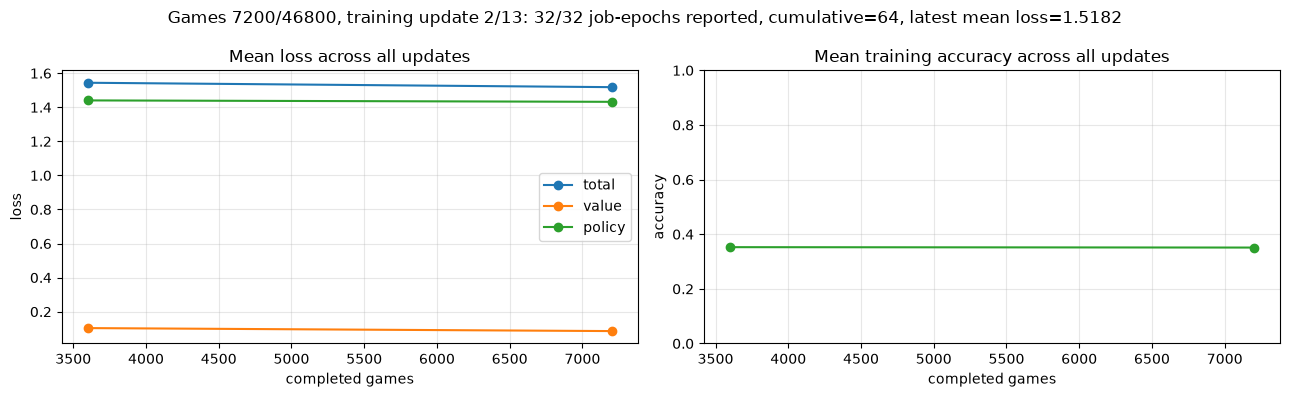

episode checkpoint training done: preprocess=11.3s training=219.4s total=232.1s


,completed_episodes,batch_episodes,output,checkpoint,training_state,training_seconds,training_mode,initial_weights,trained_episodes_for_temperature,temperature_turn0,temperature_turn_max
0,3600,3600,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,189.409076,central-device,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,0,1.2,0.292102
1,7200,3600,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,219.350938,central-device,/Users/naoki/Desktop/develop/pokemon_tgc_agent...,3600,1.2,0.292102


action temperature: trained_episodes=7200, turn0=1.2000, turn100=0.2921
parallel games: workers=9, lanes/worker=400, games=3600, pairings=136, self=yes, limits=100 turns/500 selections
balanced schedule: matches/agent=424〜424, player-sides/agent=450〜450


Traceback (most recent call last):
  File "/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent/tools/run_matches_round_robin.py", line 1408, in <module>
    main()
  File "/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent/tools/run_matches_round_robin.py", line 1085, in main
    batched_output = run_worker_batched_tournament(
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/naoki/Desktop/develop/pokemon_tgc_agent/pokemon-tcg-agent/tools/batched_tournament.py", line 3832, in run_worker_batched_tournament
    first_message = request_queue.get(timeout=0.01)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/naoki/.pyenv/versions/3.11.9/lib/python3.11/multiprocessing/queues.py", line 113, in get
    if not self._poll(timeout):
           ^^^^^^^^^^^^^^^^^^^
  File "/Users/naoki/.pyenv/versions/3.11.9/lib/python3.11/multiprocessing/connection.py", line 257, in poll
    return self._poll(timeout)
           ^^^^^^^^^^^^^^^^^^^
  F

KeyboardInterrupt: 

In [24]:
results = run_training_loop()
print(f'completed: {RUN_ROOT}')